In [1]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("loan_approval_data.csv")
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [5]:
df.nunique()

Applicant_ID          950
Applicant_Income      924
Coapplicant_Income    902
Employment_Status       4
Age                    39
Marital_Status          2
Dependents              4
Credit_Score          246
Existing_Loans          5
DTI_Ratio              51
Savings               926
Collateral_Value      942
Loan_Amount           936
Loan_Term               7
Loan_Purpose            5
Property_Area           3
Education_Level         2
Gender                  2
Employer_Category       5
Loan_Approved           2
dtype: int64

In [6]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

# Handling Null Values

In [7]:
#numerical and categorical datas NaN values are filled differently
num_cols = df.select_dtypes(include =["number"]).columns
categorical_col = df.select_dtypes(include=["object"]).columns

In [8]:
from sklearn.impute import SimpleImputer
num_imputer = SimpleImputer(strategy = "mean")
df[num_cols] = num_imputer.fit_transform(df[num_cols])

col_imputer = SimpleImputer(strategy = "most_frequent")
df[categorical_col] = col_imputer.fit_transform(df[categorical_col])

# EDA

Text(0.5, 1.0, 'Is Loan approved?')

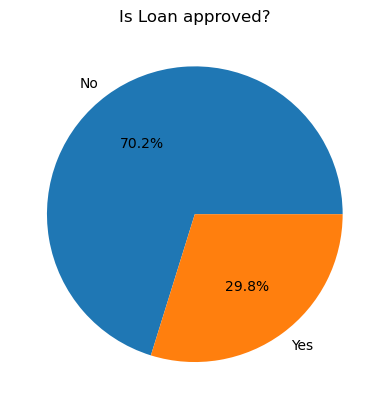

In [9]:
#percentage of loans approved
classes_count = df["Loan_Approved"].value_counts()

plt.pie(classes_count ,labels = ["No","Yes"],autopct = "%1.1f%%")
plt.title("Is Loan approved?")

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

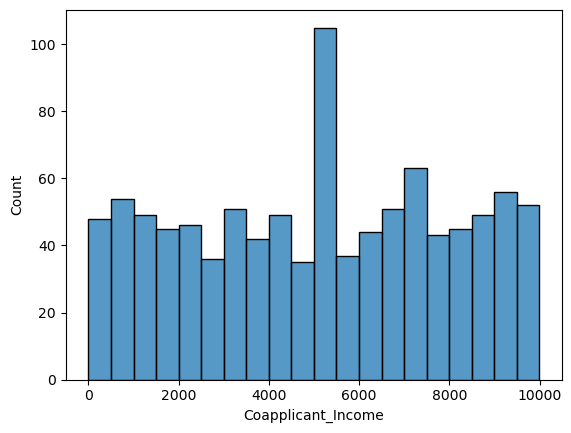

In [10]:
# checking the relation between applicant_income and loan approved
sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    bins = 20
)

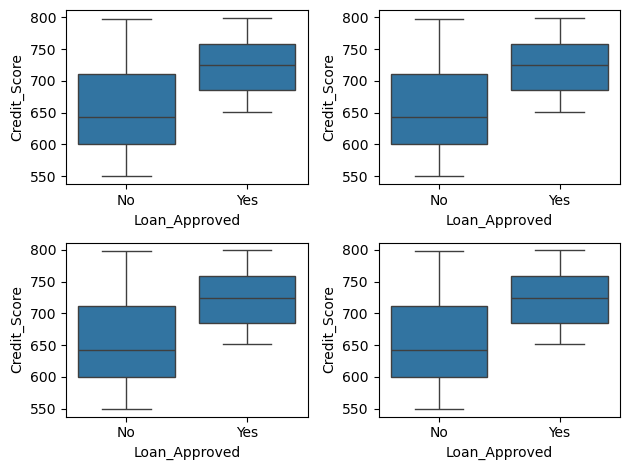

In [11]:
# Outlier detection
fig,axes = plt.subplots(2,2)

sns.boxplot( ax = axes[0,0], data = df, x = "Loan_Approved", y = "Credit_Score")
sns.boxplot( ax = axes[0,1], data = df, x = "Loan_Approved", y = "Credit_Score")

sns.boxplot( ax = axes[1,0], data = df, x = "Loan_Approved", y = "Credit_Score")
sns.boxplot( ax = axes[1,1],data = df, x = "Loan_Approved", y = "Credit_Score")

plt.tight_layout()

# Encoding

In [12]:
df.nunique()

Applicant_ID          951
Applicant_Income      925
Coapplicant_Income    903
Employment_Status       4
Age                    40
Marital_Status          2
Dependents              5
Credit_Score          247
Existing_Loans          6
DTI_Ratio              52
Savings               927
Collateral_Value      943
Loan_Amount           937
Loan_Term               7
Loan_Purpose            5
Property_Area           3
Education_Level         2
Gender                  2
Employer_Category       5
Loan_Approved           2
dtype: int64

In [13]:
df.drop("Applicant_ID", axis = 1)

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


In [14]:
#Binary Encoding
binary_cols = ["Marital_Status","Education_Level","Gender","Loan_Approved"]

for cols in binary_cols:
    df[cols] = df[cols].map({df[cols].unique()[0]:0,
                            df[cols].unique()[1]:1})

In [15]:
#Numerical Encoding
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
OHE = OneHotEncoder(drop = "first", sparse_output = False, handle_unknown='ignore')
OHE_cols = ["Employment_Status","Loan_Purpose","Property_Area","Employer_Category"]
encoded = OHE.fit_transform(df[OHE_cols])
encoded_df = pd.DataFrame(encoded, columns = OHE.get_feature_names_out(OHE_cols), index = df.index)
df = pd.concat([df.drop(columns = OHE_cols), encoded_df],axis = 1)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_ID                     1000 non-null   float64
 1   Applicant_Income                 1000 non-null   float64
 2   Coapplicant_Income               1000 non-null   float64
 3   Age                              1000 non-null   float64
 4   Marital_Status                   1000 non-null   int64  
 5   Dependents                       1000 non-null   float64
 6   Credit_Score                     1000 non-null   float64
 7   Existing_Loans                   1000 non-null   float64
 8   DTI_Ratio                        1000 non-null   float64
 9   Savings                          1000 non-null   float64
 10  Collateral_Value                 1000 non-null   float64
 11  Loan_Amount                      1000 non-null   float64
 12  Loan_Term            

# CORELATION HEATMAP

In [17]:
num_cols = df.select_dtypes(include = "number")
corr_matrix = num_cols.corr()

In [18]:
num_cols.corr()["Loan_Approved"].sort_values(ascending = False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Education_Level                    0.052920
Loan_Purpose_Personal              0.034043
Marital_Status                     0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Applicant_ID                      -0.011167
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried      

<Axes: >

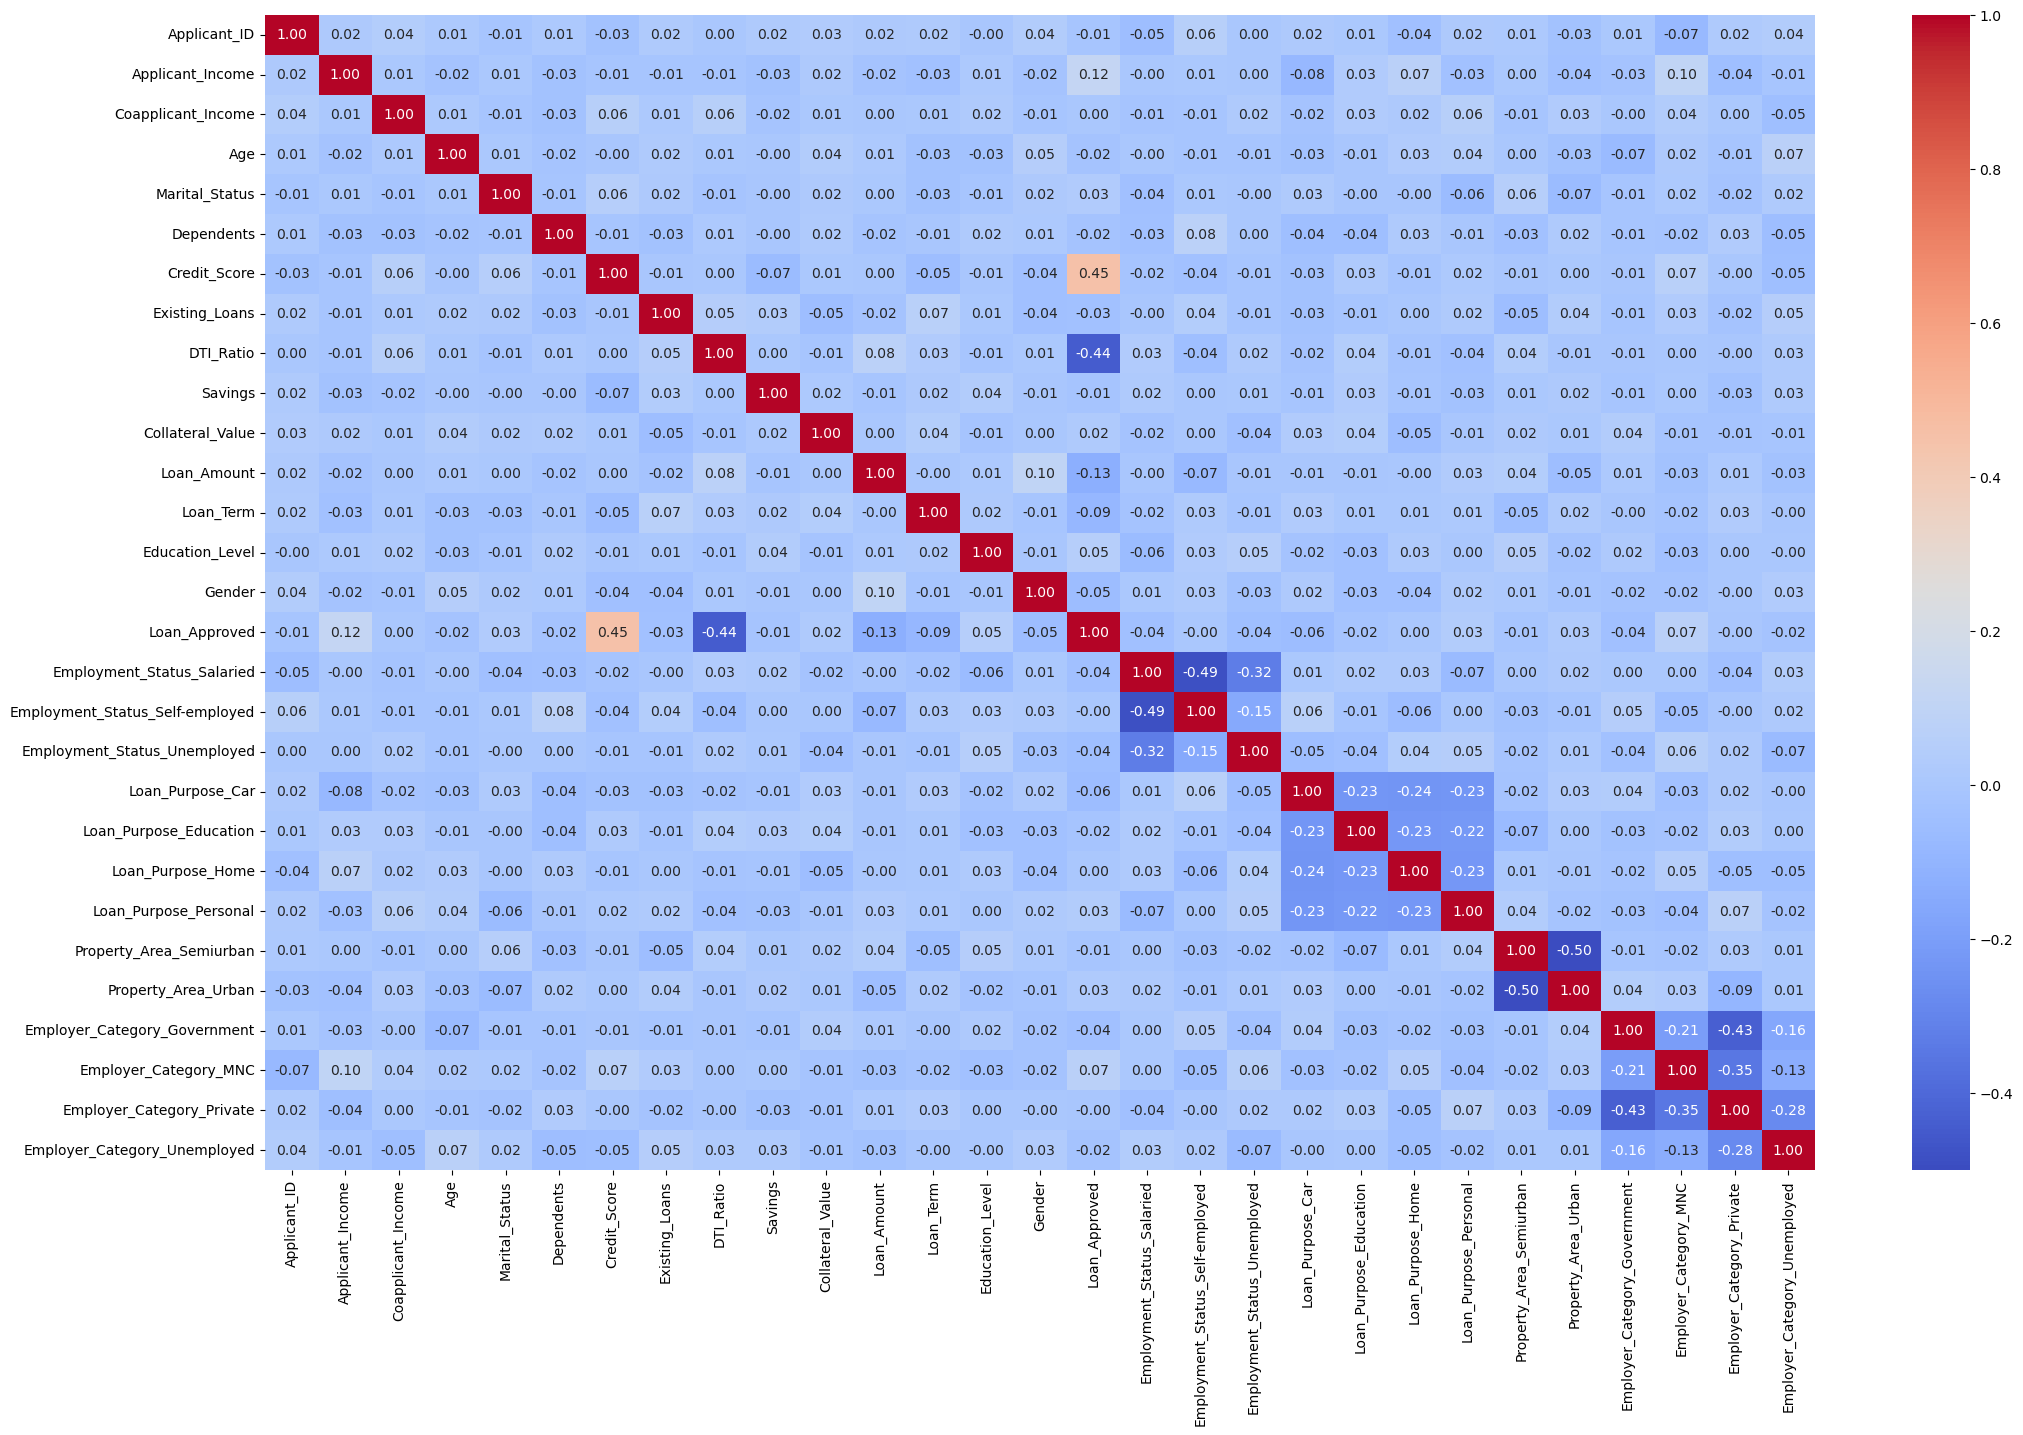

In [19]:
plt.figure(figsize=(25,15))
sns.heatmap(
    corr_matrix,
    annot = True,
    cmap = "coolwarm",
    fmt = ".2f",
    
)

# Train_Teat_Split and Feature Scaling

In [20]:
X = df.drop("Loan_Approved", axis = 1)
y = df["Loan_Approved"]

In [21]:
X_train , X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [22]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

# Evaluation of models LR , KNN, NB

In [23]:
#LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score


lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

#Evaluation
print("Precision score ", precision_score(y_test,y_pred))
print("Recall score ", recall_score(y_test,y_pred))
print("Accuracy score ", accuracy_score(y_test,y_pred))
print("F1 score ", f1_score(y_test,y_pred))
print("Confusion_matrix ", confusion_matrix(y_test,y_pred))


Precision score  0.7868852459016393
Recall score  0.7868852459016393
Accuracy score  0.87
F1 score  0.7868852459016393
Confusion_matrix  [[126  13]
 [ 13  48]]


In [24]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score


neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(X_train_scaled, y_train)
y_pred = neigh.predict(X_test_scaled)

#Evaluation
print("Precision score ", precision_score(y_test,y_pred))
print("Recall score ", recall_score(y_test,y_pred))
print("Accuracy score ", accuracy_score(y_test,y_pred))
print("F1 score ", f1_score(y_test,y_pred))
print("Confusion_matrix ", confusion_matrix(y_test,y_pred))

Precision score  0.5961538461538461
Recall score  0.5081967213114754
Accuracy score  0.745
F1 score  0.5486725663716814
Confusion_matrix  [[118  21]
 [ 30  31]]


In [25]:
#NaiveBayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score


gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
y_pred = gnb.predict(X_test_scaled)

#Evaluation
print("Precision score ", precision_score(y_test,y_pred))
print("Recall score ", recall_score(y_test,y_pred))
print("Accuracy score ", accuracy_score(y_test,y_pred))
print("F1 score ", f1_score(y_test,y_pred))
print("Confusion_matrix ", confusion_matrix(y_test,y_pred))

Precision score  0.8035714285714286
Recall score  0.7377049180327869
Accuracy score  0.865
F1 score  0.7692307692307693
Confusion_matrix  [[128  11]
 [ 16  45]]


# Feature Engineering to improve models

In [26]:
#Feature Tranform
df["DTI_SQ"] = df["DTI_Ratio"] ** 2
df["Credit_Score_SQ"] = df["Credit_Score"] ** 2

X = df.drop(columns = ["Loan_Approved","Credit_Score","DTI_Ratio"])
y = df["Loan_Approved"]

X_train , X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [27]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [28]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score


lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

#Evaluation
print("Precision score ", precision_score(y_test,y_pred))
print("Recall score ", recall_score(y_test,y_pred))
print("Accuracy score ", accuracy_score(y_test,y_pred))
print("F1 score ", f1_score(y_test,y_pred))
print("Confusion_matrix ", confusion_matrix(y_test,y_pred))

Precision score  0.7903225806451613
Recall score  0.8032786885245902
Accuracy score  0.875
F1 score  0.7967479674796748
Confusion_matrix  [[126  13]
 [ 12  49]]


In [29]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score


neigh = KNeighborsClassifier(n_neighbors=7)
neigh.fit(X_train_scaled, y_train)
y_pred = neigh.predict(X_test_scaled)

#Evaluation
print("Precision score ", precision_score(y_test,y_pred))
print("Recall score ", recall_score(y_test,y_pred))
print("Accuracy score ", accuracy_score(y_test,y_pred))
print("F1 score ", f1_score(y_test,y_pred))
print("Confusion_matrix ", confusion_matrix(y_test,y_pred))

Precision score  0.6666666666666666
Recall score  0.45901639344262296
Accuracy score  0.765
F1 score  0.5436893203883495
Confusion_matrix  [[125  14]
 [ 33  28]]


In [30]:
#NaiveBayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score


gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
y_pred = gnb.predict(X_test_scaled)

#Evaluation
print("Precision score ", precision_score(y_test,y_pred))
print("Recall score ", recall_score(y_test,y_pred))
print("Accuracy score ", accuracy_score(y_test,y_pred))
print("F1 score ", f1_score(y_test,y_pred))
print("Confusion_matrix ", confusion_matrix(y_test,y_pred))

Precision score  0.7966101694915254
Recall score  0.7704918032786885
Accuracy score  0.87
F1 score  0.7833333333333333
Confusion_matrix  [[127  12]
 [ 14  47]]
